<a href="https://colab.research.google.com/github/heigetter/Isolation_Tree/blob/main/Isolation_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

In [41]:

#Isolation Tree
class Node:
  def __init__(self):
    self.size = None
    self.left = None
    self.right = None
    self.split_dim = None
    self.split_thresh = None
  def isolation_tree(self, X, h, h_max):
    X_left = []
    X_right = []
    if h >= h_max or len(X) <= 1:
      self.size = len(X)
    else:
      q = random.randint(1, len(X[0]))
      p = random.uniform(X[:, q - 1].min(), X[:, q - 1].max())
      for i in range(len(X)):
        if X[i][q - 1] >= p:
          X_left.append(X[i])
        else:
          X_right.append(X[i])
      X_left = np.array(X_left)
      X_right = np.array(X_right)
      self.left = Node()
      self.left.isolation_tree(X_left, h + 1, h_max)
      self.right = Node()
      self.right.isolation_tree(X_right, h + 1, h_max)
      self.split_dim = q
      self.split_thresh = p

def c(n):
    if n <= 1:
        return 0
    return 2 * (np.log(n - 1) + 0.5772) - (2 * (n - 1) / n)

def sample(X, sample_size):
    index = random.sample(range(len(X)), sample_size)
    return X[index]

#Isolation Forest
def isolation_forest(X, n, sample_size):
  forest = []
  h_max = int(np.log2(sample_size))
  for i in range(n):
    X_sample = sample(X, sample_size)
    root = Node()
    root.isolation_tree(X_sample, 0, h_max)
    forest.append(root)
  return forest

#Anomaly_Score
def anomaly_score(forest, x, sample_size):
    lengths = [path_length(x, tree, 0) for tree in forest]
    return 2 ** (-np.mean(lengths) / c(sample_size))

def path_length(x, T, h):
  if T.size is not None:
    return h + T.size
  q = T.split_dim
  if x[q - 1] < T.split_thresh:
    return path_length(x, T.left, h+1)
  else:
    return path_length(x, T.right, h+1)


In [72]:
import pandas as pd

columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df = pd.read_csv("/content/kddcup.data.corrected", sep=",", names=columns, index_col=None)

In [73]:
df = df[df["service"] == "http"]
df = df.drop("service", axis=1)
columns.remove("service")

In [75]:
top_features = [
    'src_bytes', 'dst_host_srv_serror_rate', 'same_srv_rate',
    'num_compromised', 'dst_host_same_srv_rate', 'dst_host_serror_rate',
    'hot', 'serror_rate', 'srv_serror_rate', 'count'
]

df_feat = df[top_features].copy()
df_feat[['src_bytes']] = StandardScaler().fit_transform(df_feat[['src_bytes']])

X = df_feat.values

In [76]:
forest = isolation_forest(X, n=100, sample_size=256)

scores = [anomaly_score(forest, x, sample_size=256) for x in X]

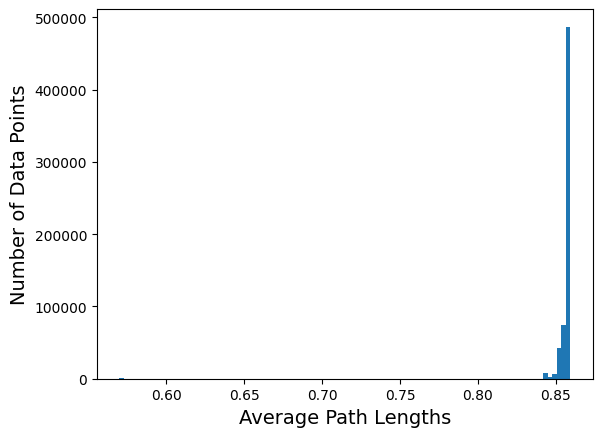

In [81]:
plt.hist(scores, bins=100)
plt.xlabel('Average Path Lengths', fontsize=14)
plt.ylabel('Number of Data Points', fontsize=14)
plt.show()

In [78]:
df['score'] = scores
print(df.groupby('label')['score'].mean().sort_values())

label
neptune.      0.676649
nmap.         0.802606
satan.        0.809618
portsweep.    0.810970
ipsweep.      0.837557
back.         0.842991
phf.          0.844391
normal.       0.856993
Name: score, dtype: float64


In [79]:
for p in [1, 2, 3, 5]:
    threshold = np.percentile(scores, p)
    df['anomaly'] = df['score'] < threshold

    tp = df[(df['anomaly'] == True) & (df['label'] != 'normal.')].shape[0]
    fp = df[(df['anomaly'] == True) & (df['label'] == 'normal.')].shape[0]
    fn = df[(df['anomaly'] == False) & (df['label'] != 'normal.')].shape[0]

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Percentil {p}%: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

Percentil 1%: Precision=0.586, Recall=0.884, F1=0.705
Percentil 2%: Precision=0.322, Recall=0.983, F1=0.485
Percentil 3%: Precision=0.230, Recall=0.997, F1=0.374
Percentil 5%: Precision=0.151, Recall=0.998, F1=0.263
